# Phishing URL Detection — ML Model Comparison

**Dataset:** UCI Phishing Websites (Mohammad et al., 2012)  
**Task:** Binary classification — Phishing (`1`) vs Legitimate (`-1`)  
**Models:** Random Forest · XGBoost · Logistic Regression

---

### Feature Encoding Key
- `1`  → Phishing indicator (bad signal)
- `-1` → Legitimate indicator (good signal)
- `0`  → Suspicious / neutral

### Target (`class`)
- `1`  → Phishing
- `-1` → Legitimate

## 1. Imports & Setup

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
print('All imports successful ✅')

All imports successful ✅


## 2. Load Data

In [5]:
df = pd.read_csv('phishing.csv')

# Drop index column if present
if 'Index' in df.columns:
    df = df.drop(columns=['Index'])

print(f'Shape: {df.shape}')
df.head()

Shape: (11054, 31)


,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,Favicon,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,-1,0,-1,1,-1,-1,1,1,-1,1,...,1,1,1,1,1,-1,1,-1,-1,1


## 3. Exploratory Data Analysis (EDA)

In [6]:
# Basic info
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Unique values per column ===')
print(df.nunique())

=== Data Types ===
UsingIP                int64
LongURL                int64
ShortURL               int64
Symbol@                int64
Redirecting//          int64
PrefixSuffix-          int64
SubDomains             int64
HTTPS                  int64
DomainRegLen           int64
Favicon                int64
NonStdPort             int64
HTTPSDomainURL         int64
RequestURL             int64
AnchorURL              int64
LinksInScriptTags      int64
ServerFormHandler      int64
InfoEmail              int64
AbnormalURL            int64
WebsiteForwarding      int64
StatusBarCust          int64
DisableRightClick      int64
UsingPopupWindow       int64
IframeRedirection      int64
AgeofDomain            int64
DNSRecording           int64
WebsiteTraffic         int64
PageRank               int64
GoogleIndex            int64
LinksPointingToPage    int64
StatsReport            int64
class                  int64
dtype: object

=== Missing Values ===
UsingIP                0
LongURL            

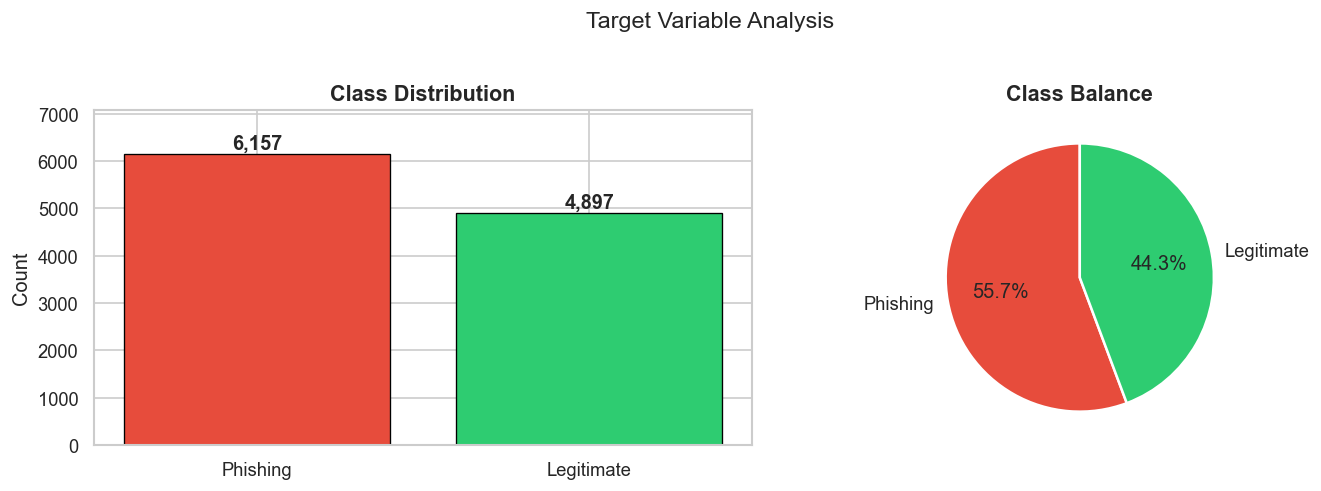


Phishing: 6,157 | Legitimate: 4,897


In [7]:
# Class distribution
class_counts = df['class'].value_counts()
labels = {1: 'Phishing', -1: 'Legitimate'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
ax = axes[0]
bars = ax.bar(
    [labels.get(k, k) for k in class_counts.index],
    class_counts.values,
    color=['#E74C3C', '#2ECC71'],
    edgecolor='black', linewidth=0.8
)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, class_counts.max() * 1.15)

# Pie chart
ax2 = axes[1]
ax2.pie(
    class_counts.values,
    labels=[labels.get(k, k) for k in class_counts.index],
    autopct='%1.1f%%',
    colors=['#E74C3C', '#2ECC71'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax2.set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nPhishing: {class_counts.get(1, 0):,} | Legitimate: {class_counts.get(-1, 0):,}")

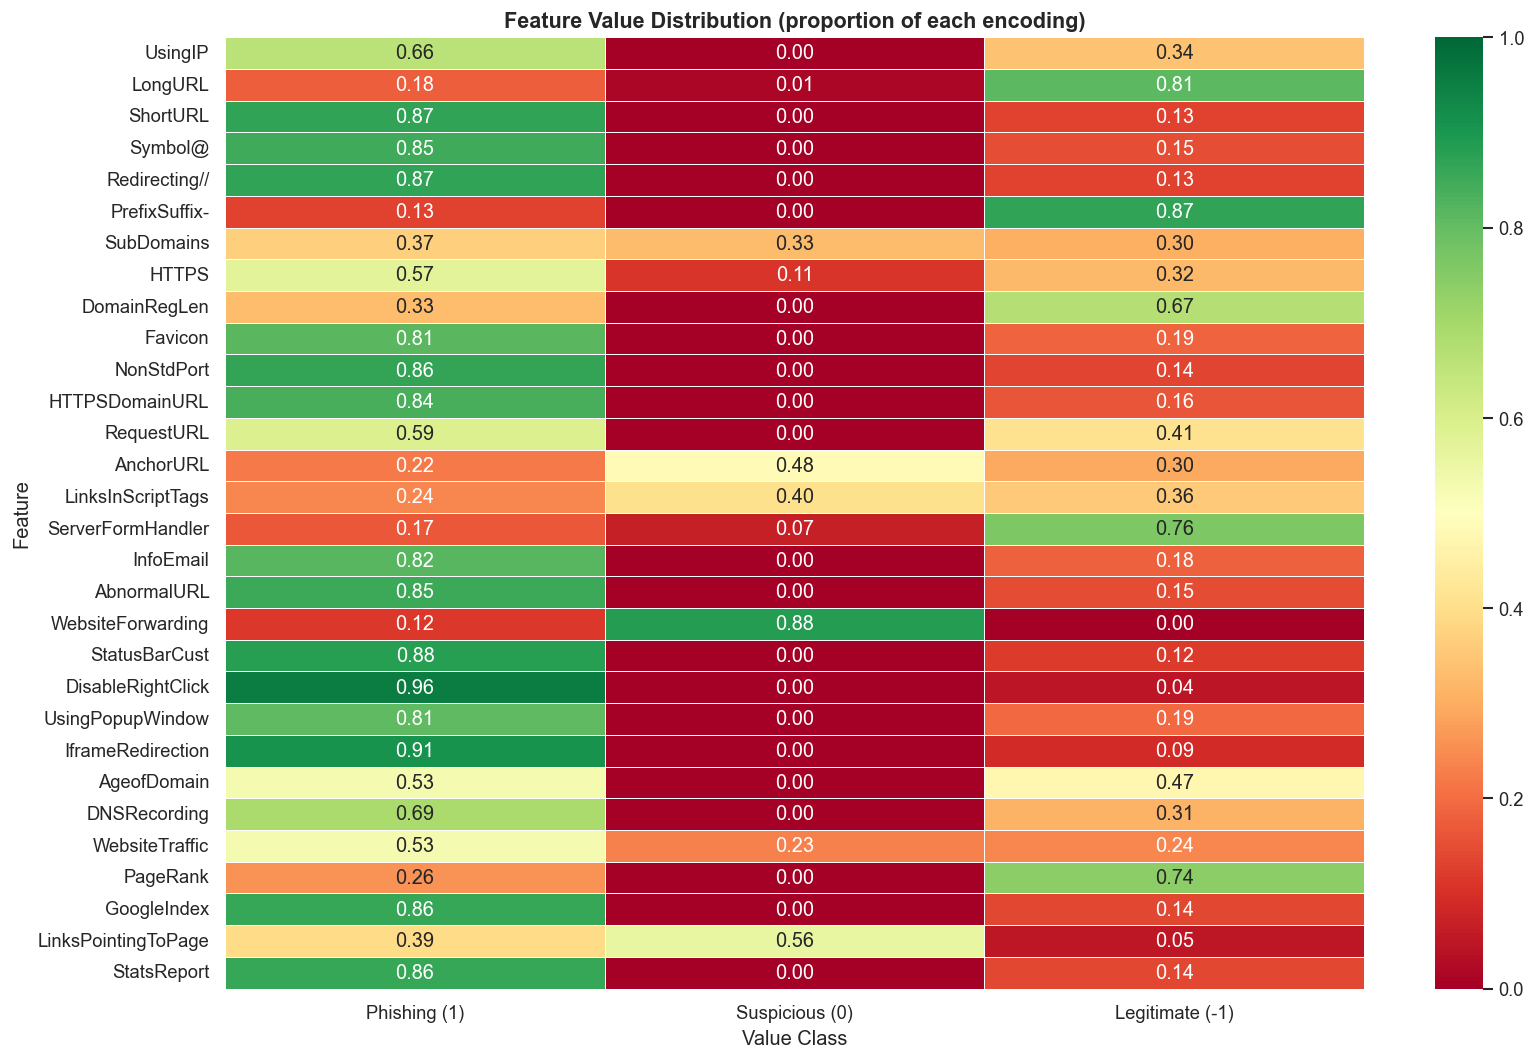

In [8]:
# Feature value distribution heatmap (proportion of 1, 0, -1 per feature)
feature_cols = [c for c in df.columns if c != 'class']

dist_data = {}
for col in feature_cols:
    counts = df[col].value_counts(normalize=True)
    dist_data[col] = {
        'Phishing (1)':  counts.get(1, 0),
        'Suspicious (0)': counts.get(0, 0),
        'Legitimate (-1)': counts.get(-1, 0),
    }

dist_df = pd.DataFrame(dist_data).T

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    dist_df,
    annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_title('Feature Value Distribution (proportion of each encoding)', fontsize=13, fontweight='bold')
ax.set_xlabel('Value Class')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

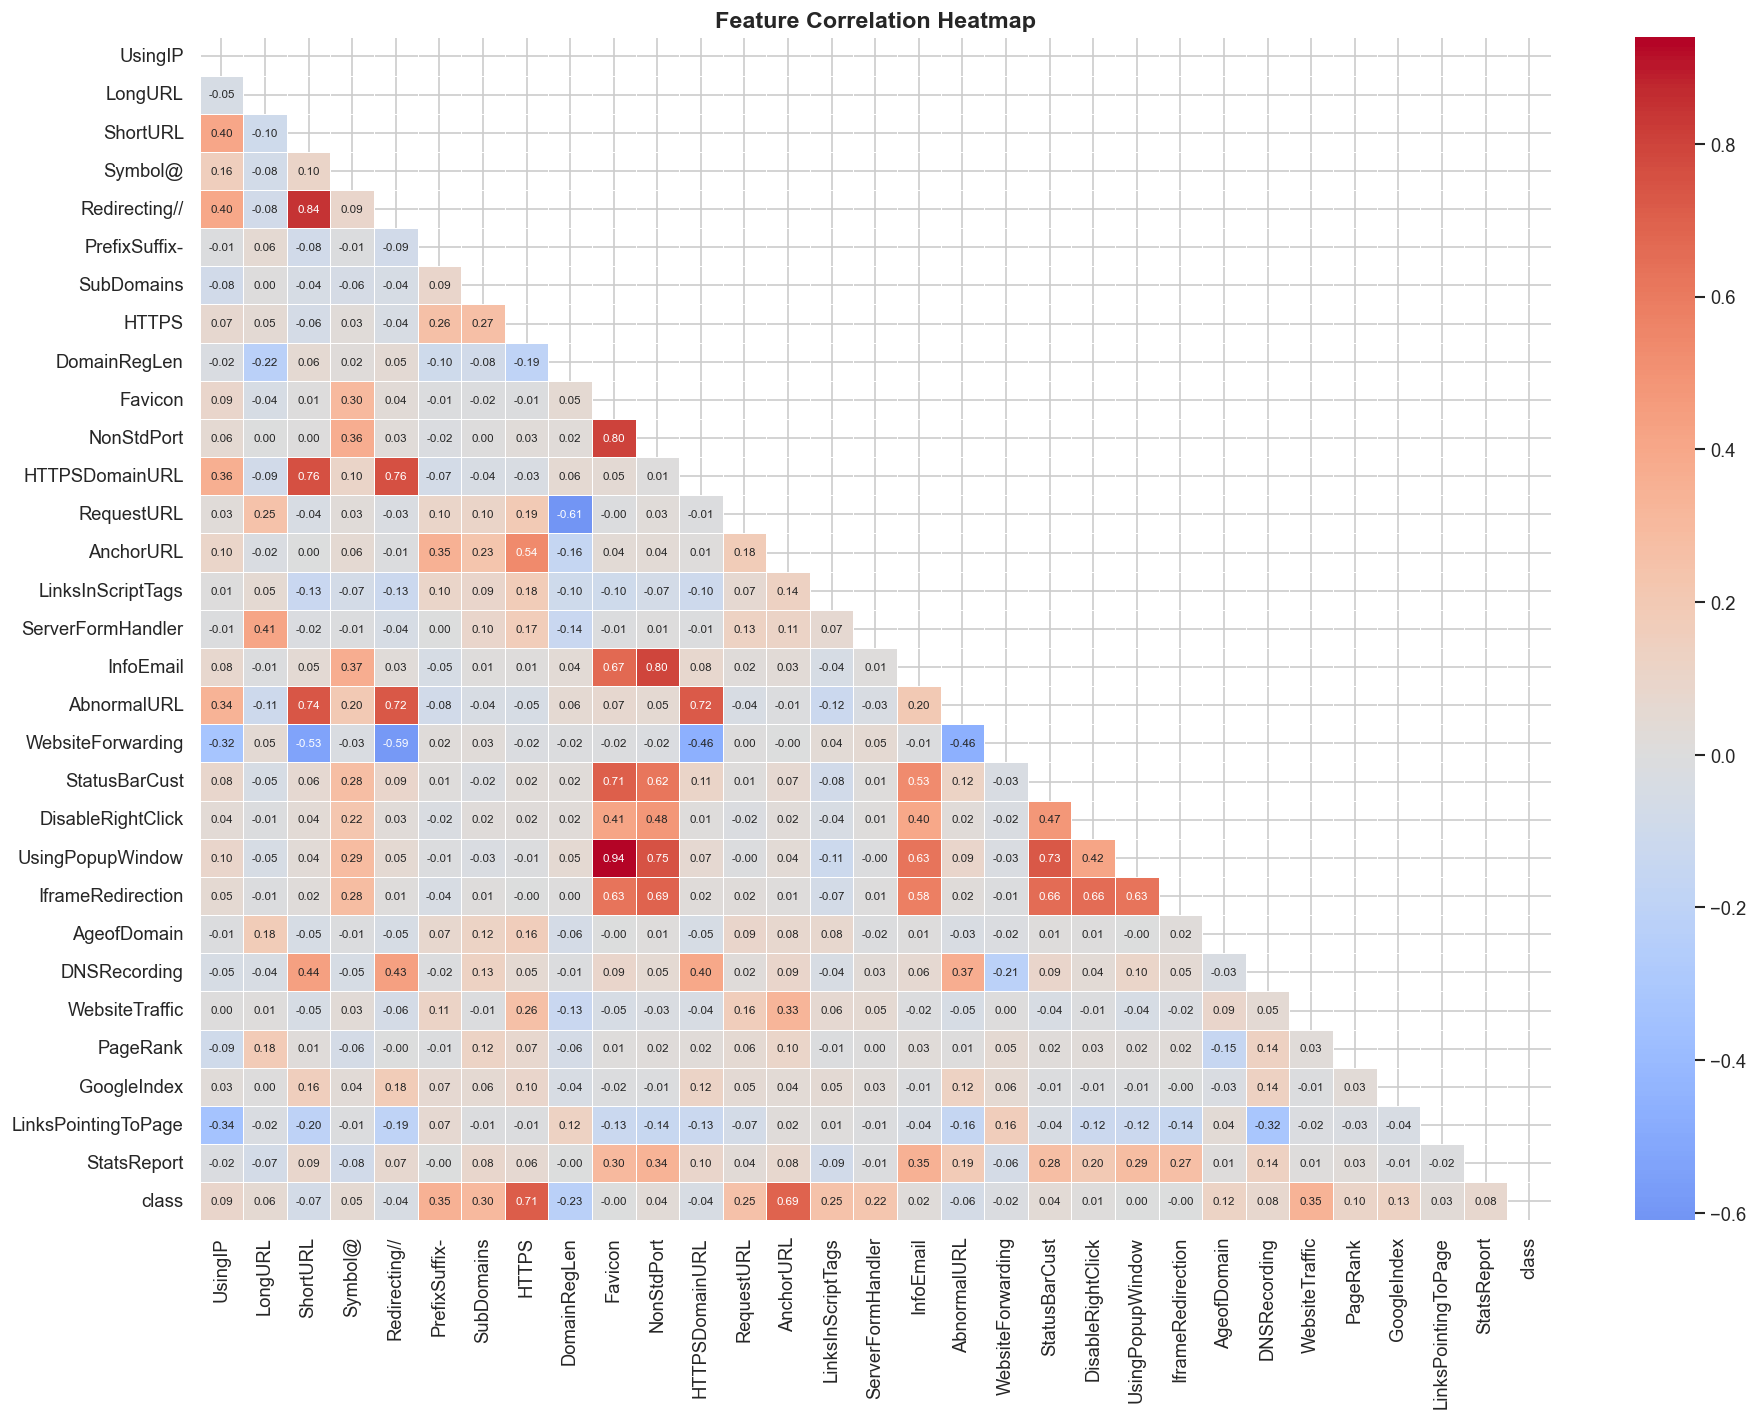

In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.4,
    ax=ax, annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [10]:
X = df.drop(columns=['class'])
y = df['class']

# XGBoost requires labels in [0, n_classes-1], so we remap for XGB only
# For RF and LR we keep original {-1, 1}
y_xgb = y.map({-1: 0, 1: 1})  # 0 = Legitimate, 1 = Phishing

# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
_, _, y_train_xgb, y_test_xgb = train_test_split(
    X, y_xgb, test_size=0.2, random_state=RANDOM_STATE, stratify=y_xgb
)

print(f'Train size : {X_train.shape[0]:,}')
print(f'Test size  : {X_test.shape[0]:,}')
print(f'\nTrain class balance:\n{y_train.value_counts()}')
print(f'\nTest class balance:\n{y_test.value_counts()}')

Train size : 8,843
Test size  : 2,211

Train class balance:
class
 1    4925
-1    3918
Name: count, dtype: int64

Test class balance:
class
 1    1232
-1     979
Name: count, dtype: int64


## 5. Model Training

We train three models:
1. **Random Forest** — ensemble of decision trees, robust to noise
2. **XGBoost** — gradient-boosted trees, typically highest performance
3. **Logistic Regression** — linear baseline for comparison

In [13]:
# ── Helper: evaluate any trained model ──────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, xgb_mode=False):
    """
    Returns a dict of metrics and prints a classification report.
    xgb_mode=True → y labels are {0,1}; we relabel for display.
    """
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)

    target_names = ['Legitimate', 'Phishing'] if xgb_mode else ['Legitimate (-1)', 'Phishing (1)']

    print("\n" + "="*55)
    print(f"  {name}")
    print("="*55)
    print(f'  Accuracy : {acc:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=target_names)}')

    return {'Model': name, 'Accuracy': acc, 'ROC-AUC': auc,
            'y_te': y_te, 'y_pred': y_pred, 'y_prob': y_prob,
            'xgb_mode': xgb_mode}

In [14]:
# ── Model 1: Random Forest ───────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_results = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)


  Random Forest
  Accuracy : 0.9711
  ROC-AUC  : 0.9952

                 precision    recall  f1-score   support

Legitimate (-1)       0.98      0.96      0.97       979
   Phishing (1)       0.97      0.98      0.97      1232

       accuracy                           0.97      2211
      macro avg       0.97      0.97      0.97      2211
   weighted avg       0.97      0.97      0.97      2211



In [15]:
# ── Model 2: XGBoost ─────────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train, y_train_xgb)
xgb_results = evaluate_model('XGBoost', xgb, X_train, y_train_xgb,
                              X_test, y_test_xgb, xgb_mode=True)


  XGBoost
  Accuracy : 0.9701
  ROC-AUC  : 0.9966

              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.97       979
    Phishing       0.97      0.98      0.97      1232

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



In [16]:
# ── Model 3: Logistic Regression ─────────────────────────────────────────────
lr = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    C=1.0,
    random_state=RANDOM_STATE
)
lr.fit(X_train, y_train)
lr_results = evaluate_model('Logistic Regression', lr, X_train, y_train, X_test, y_test)


  Logistic Regression
  Accuracy : 0.9389
  ROC-AUC  : 0.9824

                 precision    recall  f1-score   support

Legitimate (-1)       0.94      0.92      0.93       979
   Phishing (1)       0.94      0.95      0.95      1232

       accuracy                           0.94      2211
      macro avg       0.94      0.94      0.94      2211
   weighted avg       0.94      0.94      0.94      2211



In [26]:
# ── Model 4: Gradient Boosting ────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
gb_results = evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test)
 


  Gradient Boosting
  Accuracy : 0.9711
  ROC-AUC  : 0.9961

                 precision    recall  f1-score   support

Legitimate (-1)       0.98      0.96      0.97       979
   Phishing (1)       0.97      0.98      0.97      1232

       accuracy                           0.97      2211
      macro avg       0.97      0.97      0.97      2211
   weighted avg       0.97      0.97      0.97      2211



## 6. Model Comparison

In [27]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': r['Model'], 'Accuracy': r['Accuracy'], 'ROC-AUC': r['ROC-AUC']}
    for r in [rf_results, xgb_results, gb_results, lr_results]
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
 
summary['Accuracy'] = summary['Accuracy'].map('{:.4f}'.format)
summary['ROC-AUC']  = summary['ROC-AUC'].map('{:.4f}'.format)
 
print('\n=== Model Comparison Summary ===')
display(summary)


=== Model Comparison Summary ===


,Model,Accuracy,ROC-AUC
0,XGBoost,0.9701,0.9966
1,Gradient Boosting,0.9711,0.9961
2,Random Forest,0.9711,0.9952
3,Logistic Regression,0.9389,0.9824


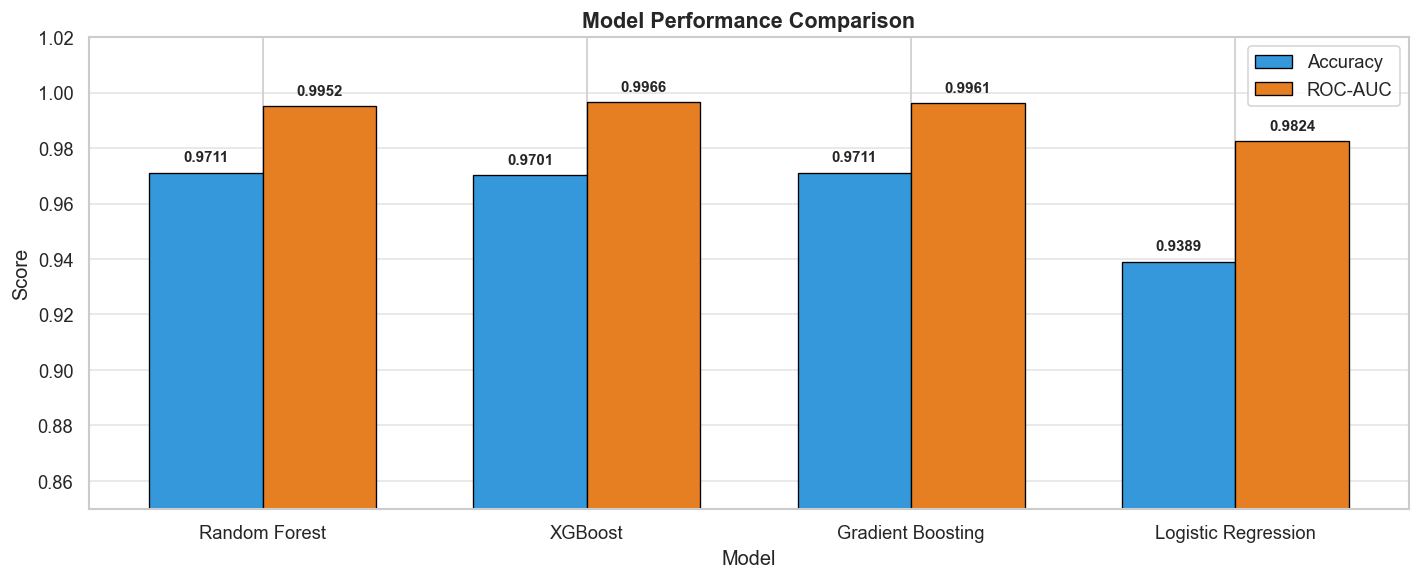

In [28]:
# ── Accuracy & AUC bar chart ──────────────────────────────────────────────────
results_list = [rf_results, xgb_results, gb_results, lr_results]
model_names  = [r['Model'] for r in results_list]
accuracies   = [r['Accuracy'] for r in results_list]
aucs         = [r['ROC-AUC'] for r in results_list]
 
x = np.arange(len(model_names))
width = 0.35
colors = ['#3498DB', '#E67E22']
 
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color=colors[0], edgecolor='black', linewidth=0.8)
b2 = ax.bar(x + width/2, aucs,       width, label='ROC-AUC',  color=colors[1], edgecolor='black', linewidth=0.8)
 
for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.yaxis.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()
 

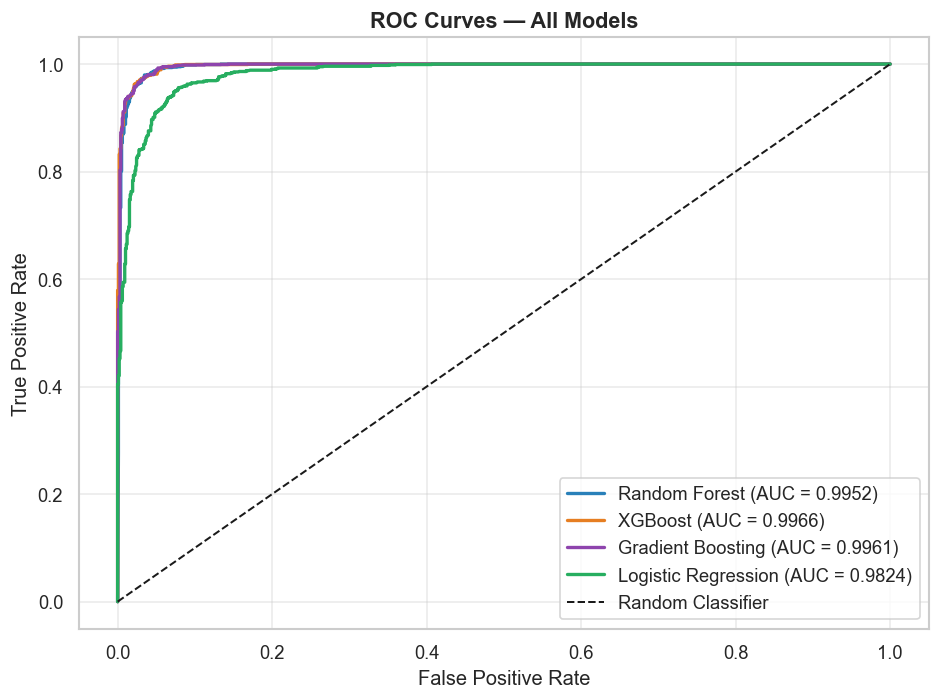

In [29]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
 
palette = ['#2980B9', '#E67E22', '#8E44AD', '#27AE60']  # RF, XGB, GB, LR
for result, color in zip(results_list, palette):
    y_te   = result['y_te']
    y_prob = result['y_prob']
    fpr, tpr, _ = roc_curve(y_te, y_prob, pos_label=1)
    auc_score   = roc_auc_score(y_te, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{result['Model']} (AUC = {auc_score:.4f})")
 
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

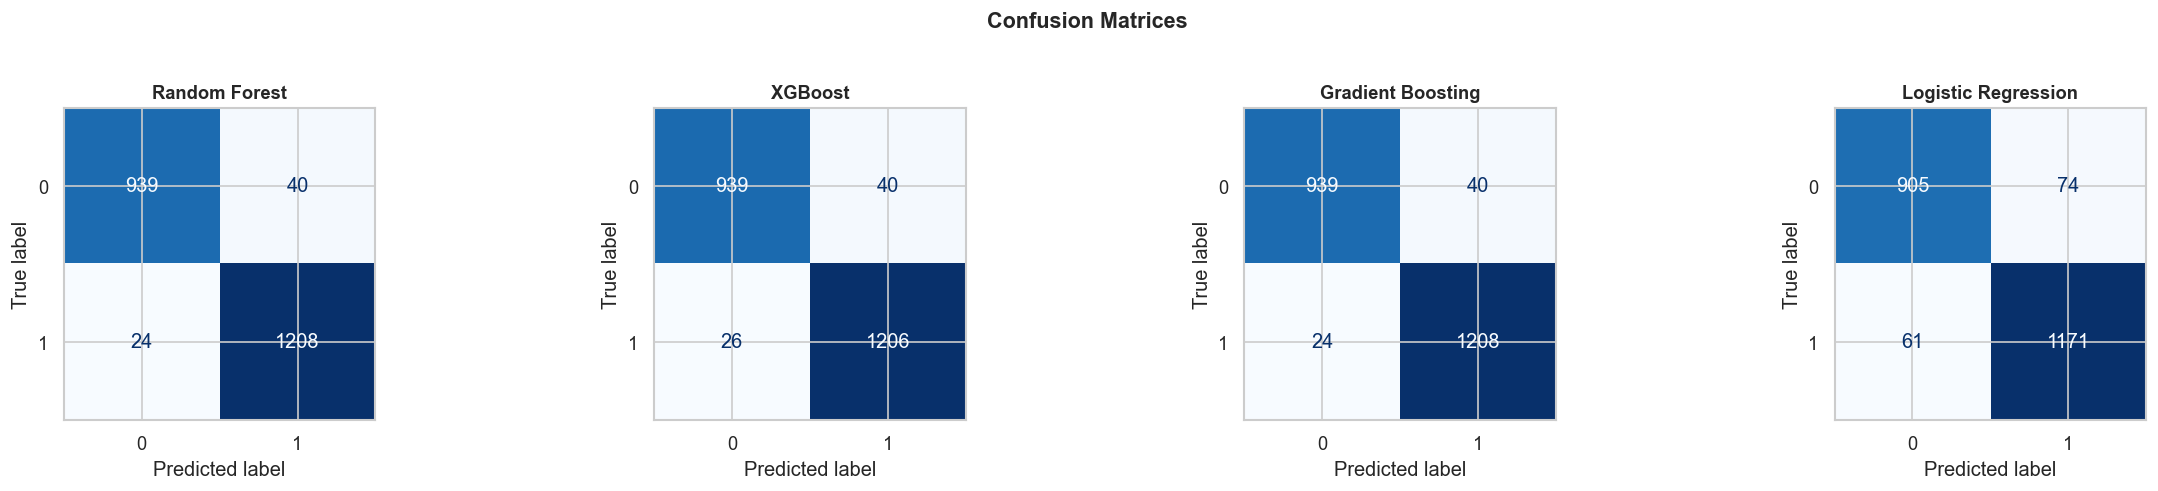

In [30]:
# ── Confusion Matrices ────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
 
for ax, result in zip(axes, results_list):
    cm = confusion_matrix(result['y_te'], result['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(result['Model'], fontsize=11, fontweight='bold')
 
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
 

## 7. Feature Importance

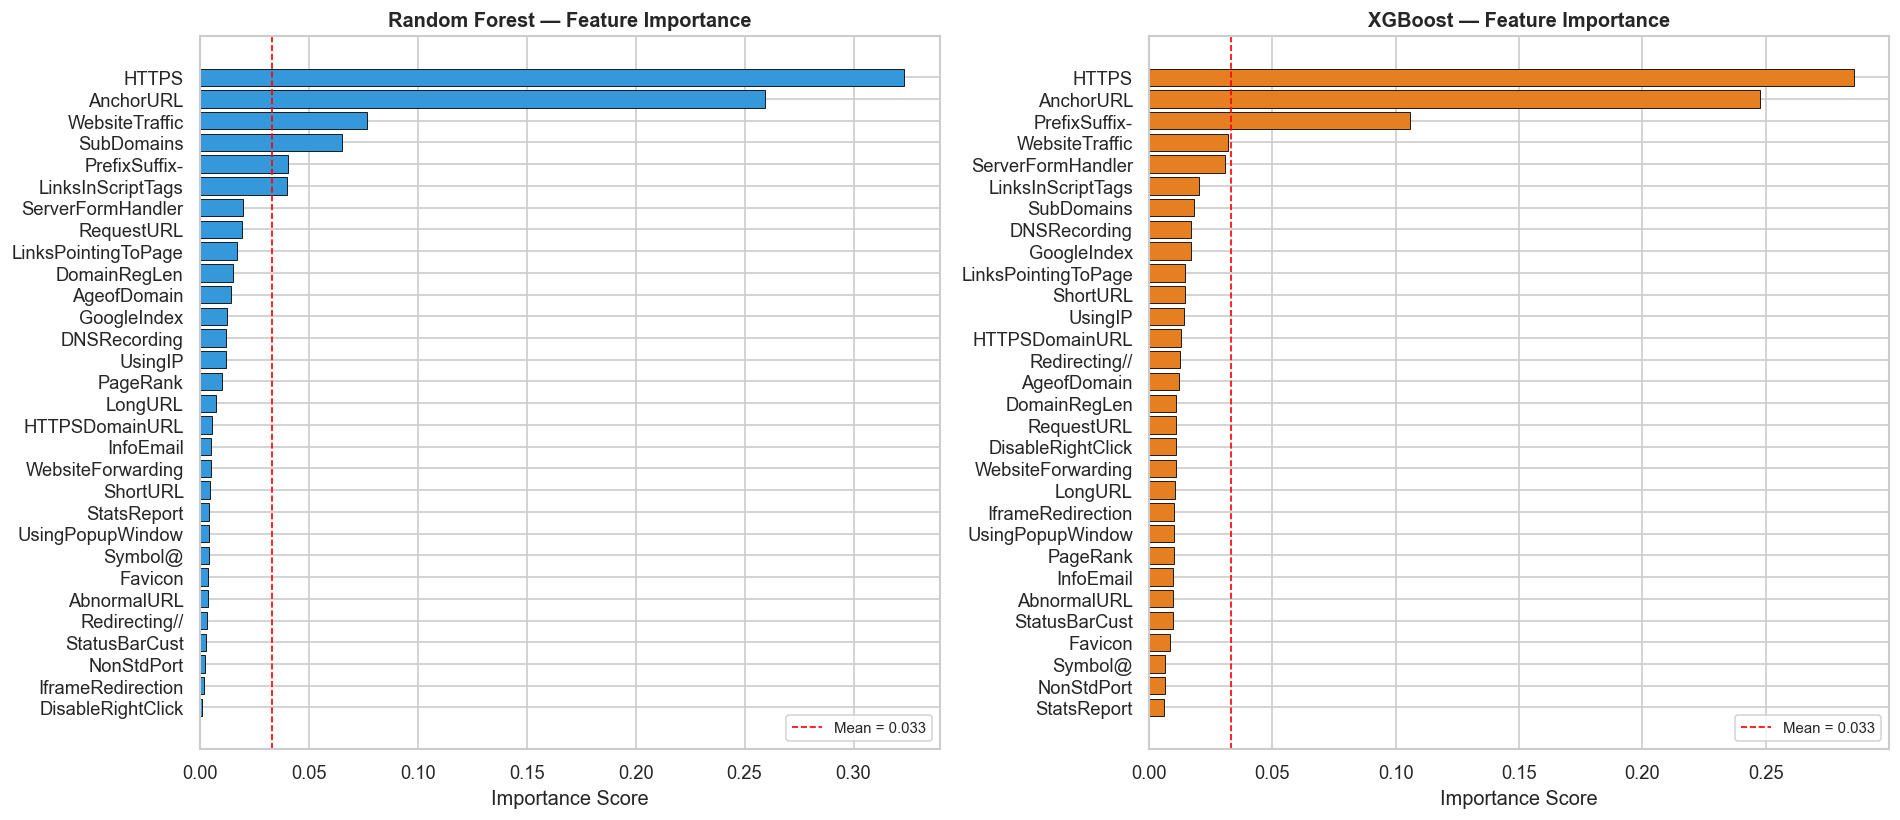

In [21]:
# Random Forest feature importance
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_importance = rf_importance.sort_values(ascending=False)

# XGBoost feature importance
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns)
xgb_importance = xgb_importance.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, importance, title, color in [
    (axes[0], rf_importance,  'Random Forest — Feature Importance', '#3498DB'),
    (axes[1], xgb_importance, 'XGBoost — Feature Importance',       '#E67E22'),
]:
    bars = ax.barh(importance.index[::-1], importance.values[::-1],
                   color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.axvline(x=importance.mean(), color='red', linestyle='--',
               linewidth=1, label=f'Mean = {importance.mean():.3f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

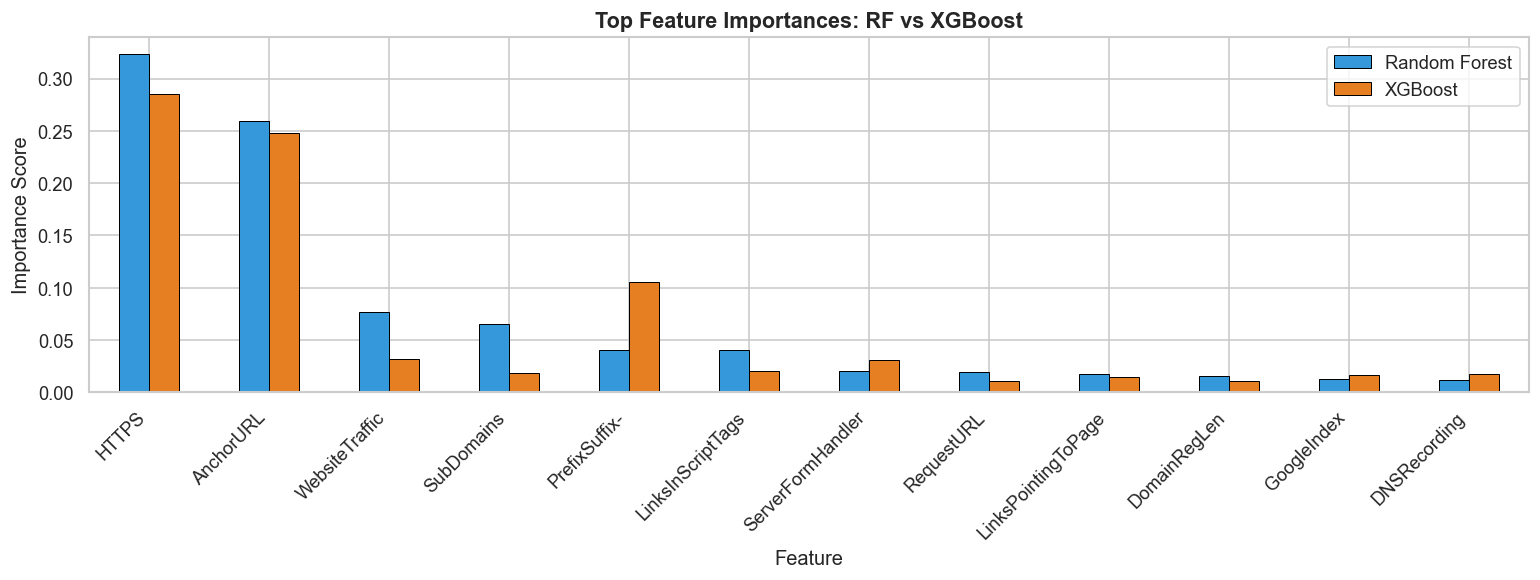

In [32]:
# Top 10 features side-by-side comparison
top10_rf  = rf_importance.head(10)
top10_xgb = xgb_importance.head(10)

all_top = list(set(top10_rf.index) | set(top10_xgb.index))
compare_df = pd.DataFrame({
    'Random Forest': rf_importance[all_top],
    'XGBoost':       xgb_importance[all_top]
}).sort_values('Random Forest', ascending=False)

compare_df.plot(kind='bar', figsize=(13, 5), color=['#3498DB', '#E67E22'],
                edgecolor='black', linewidth=0.6)
plt.title('Top Feature Importances: RF vs XGBoost', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Cross-Validation (5-Fold Stratified)

In [31]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
cv_models = [
    ('Random Forest',       rf,  X, y),
    ('XGBoost',             xgb, X, y_xgb),
    ('Gradient Boosting',   gb,  X, y),
    ('Logistic Regression', lr,  X, y),
]
 
cv_results = {}
for name, model, X_data, y_data in cv_models:
    scores = cross_val_score(model, X_data, y_data, cv=cv,
                              scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')
 
print('\nDone ✅')

Random Forest              CV Accuracy: 0.9683 ± 0.0035
XGBoost                    CV Accuracy: 0.9696 ± 0.0025
Gradient Boosting          CV Accuracy: 0.9687 ± 0.0028
Logistic Regression        CV Accuracy: 0.9273 ± 0.0041

Done ✅


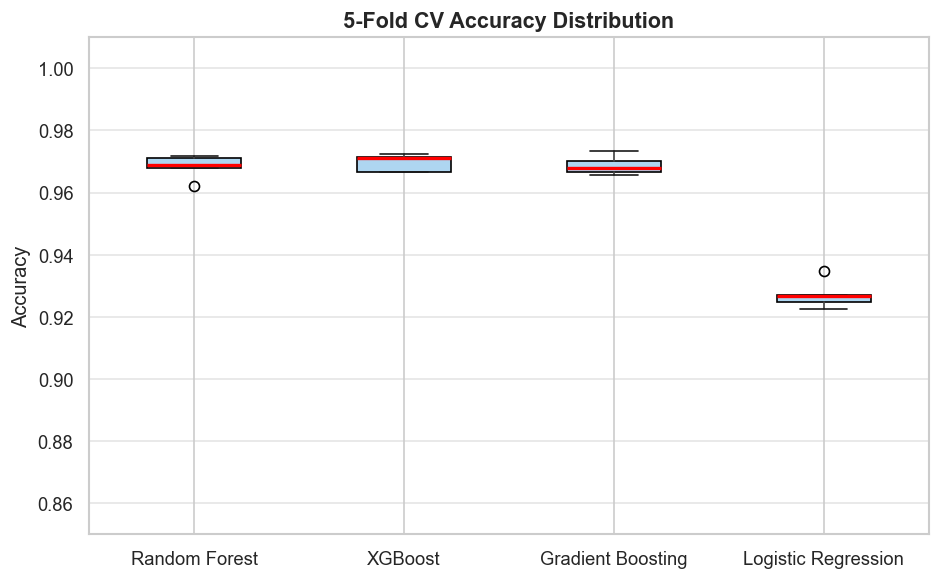

In [33]:
# CV boxplot
fig, ax = plt.subplots(figsize=(8, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'),
               medianprops=dict(color='red', linewidth=2))

ax.set_title('5-Fold CV Accuracy Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.85, 1.01)
ax.yaxis.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

,Logistic Regression,Random Forest,Gradient Boosting,XGBoost ✅
Aspect,,,,
Type,Linear,Ensemble (Bagging),Ensemble (Boosting),Ensemble (Boosting)
Interpretability,High,Medium,Low,Low
Training Speed,Fast,Moderate,Slow,Moderate
Handles Feature Interactions,No,Yes,Yes,Yes
Test Accuracy,93.89%,97.11%,97.11%,97.01%
ROC-AUC,0.9824,0.9952,0.9961,0.9966
CV Accuracy,92.73%,96.83%,96.87%,96.96%
CV Std Dev,±0.0041,±0.0035,±0.0028,±0.0025
Train-Test Gap,1.16%,0.28%,0.24%,0.05% ← lowest


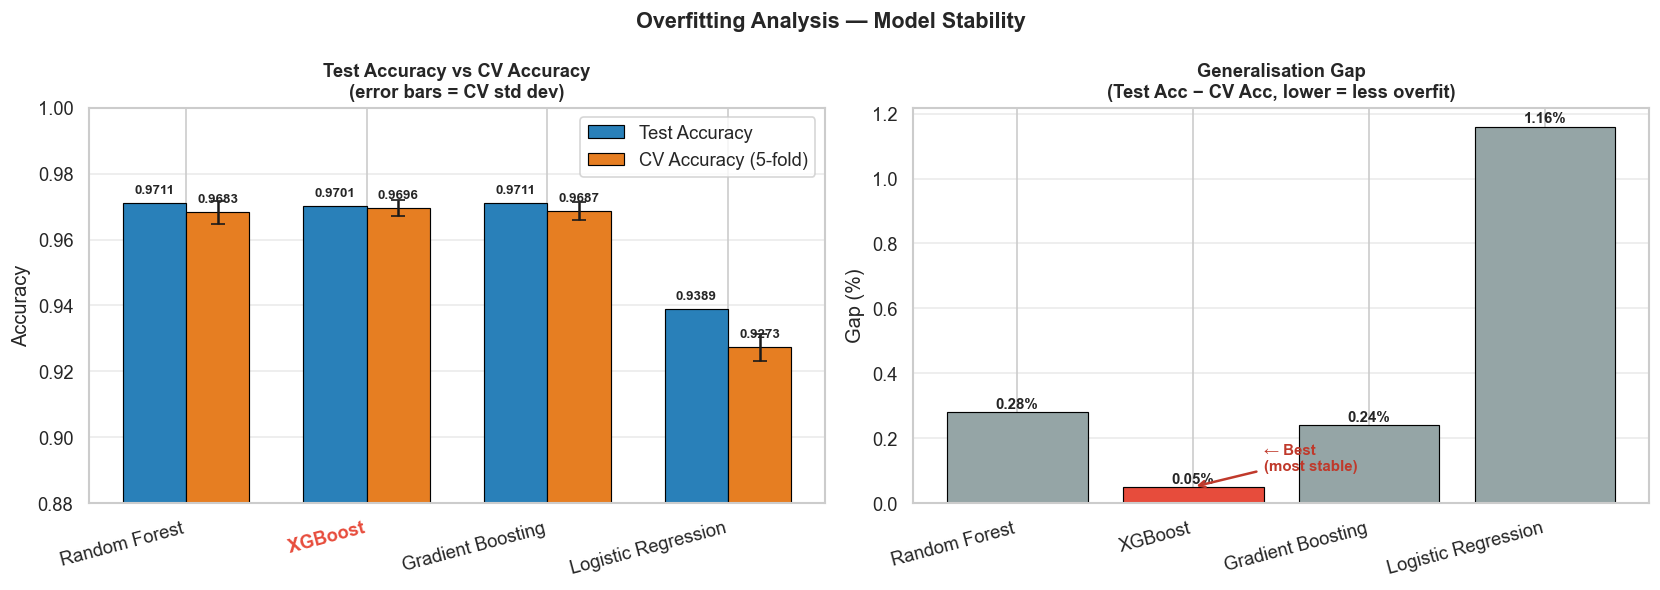


╔══════════════════════════════════════════════════════════════════╗
║               MODEL SELECTION: XGBoost                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Why XGBoost?                                                    ║
║  ─────────────────────────────────────────────────────────────   ║
║  ✅ Highest ROC-AUC      : 0.9966 (best discrimination power)   ║
║  ✅ Lowest CV Std Dev    : ±0.0025 (most consistent across folds)║
║  ✅ Smallest Overfit Gap : 0.05%  (test ≈ CV — no overfitting)  ║
║  ✅ Competitive Accuracy : 97.01% on held-out test set           ║
║                                                                  ║
║  Why not Random Forest / Gradient Boosting?                      ║
║  ─────────────────────────────────────────────────────────────   ║
║  Same test accuracy (97.11%) but higher train-test gap           ║
║  (0.28% and 0.24%) and higher CV varia

In [34]:

# ── CELL 9a: Updated Final Summary Table ────────────────────────────────────
 
# ## 9. Final Summary & Model Selection
 
summary_table = pd.DataFrame({
    'Aspect': [
        'Type', 'Interpretability', 'Training Speed',
        'Handles Feature Interactions', 'Test Accuracy',
        'ROC-AUC', 'CV Accuracy', 'CV Std Dev', 'Train-Test Gap'
    ],
    'Logistic Regression': [
        'Linear', 'High', 'Fast',
        'No', '93.89%',
        '0.9824', '92.73%', '±0.0041', '1.16%'
    ],
    'Random Forest': [
        'Ensemble (Bagging)', 'Medium', 'Moderate',
        'Yes', '97.11%',
        '0.9952', '96.83%', '±0.0035', '0.28%'
    ],
    'Gradient Boosting': [
        'Ensemble (Boosting)', 'Low', 'Slow',
        'Yes', '97.11%',
        '0.9961', '96.87%', '±0.0028', '0.24%'
    ],
    'XGBoost ✅': [
        'Ensemble (Boosting)', 'Low', 'Moderate',
        'Yes', '97.01%',
        '0.9966', '96.96%', '±0.0025', '0.05% ← lowest'
    ],
})
summary_table = summary_table.set_index('Aspect')
display(summary_table)
 
 
# ── CELL 9b: Overfitting Analysis Plot ──────────────────────────────────────
 
model_names_all = ['Random Forest', 'XGBoost', 'Gradient Boosting', 'Logistic Regression']
test_accs  = [0.9711, 0.9701, 0.9711, 0.9389]
cv_accs    = [0.9683, 0.9696, 0.9687, 0.9273]
cv_stds    = [0.0035, 0.0025, 0.0028, 0.0041]
gaps       = [abs(t - c) for t, c in zip(test_accs, cv_accs)]
 
x = np.arange(len(model_names_all))
width = 0.35
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: Test vs CV accuracy
ax = axes[0]
b1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',
            color='#2980B9', edgecolor='black', linewidth=0.7)
b2 = ax.bar(x + width/2, cv_accs,  width, label='CV Accuracy (5-fold)',
            color='#E67E22', edgecolor='black', linewidth=0.7,
            yerr=cv_stds, capsize=4, error_kw={'linewidth': 1.5})
 
for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
 
ax.set_title('Test Accuracy vs CV Accuracy\n(error bars = CV std dev)', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names_all, rotation=15, ha='right')
ax.set_ylim(0.88, 1.00)
ax.legend()
ax.yaxis.grid(True, alpha=0.4)
 
# Highlight winner
ax.get_xticklabels()[1].set_color('#E74C3C')
ax.get_xticklabels()[1].set_fontweight('bold')
 
# Right: Overfitting gap (lower = better)
ax2 = axes[1]
bar_colors = ['#95A5A6', '#E74C3C', '#95A5A6', '#95A5A6']
bars = ax2.bar(model_names_all, [g * 100 for g in gaps],
               color=bar_colors, edgecolor='black', linewidth=0.7)
 
for bar, gap in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{gap*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
ax2.set_title('Generalisation Gap\n(Test Acc − CV Acc, lower = less overfit)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Gap (%)')
ax2.set_xticklabels(model_names_all, rotation=15, ha='right')
ax2.yaxis.grid(True, alpha=0.4)
 
# Star annotation on XGBoost bar
ax2.annotate('← Best\n(most stable)', xy=(1, gaps[1]*100), xytext=(1.4, gaps[1]*100 + 0.05),
             fontsize=9, color='#C0392B', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))
 
plt.suptitle('Overfitting Analysis — Model Stability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
 
# ── CELL 9c: Model Selection Rationale (printed) ────────────────────────────
 
print("""
╔══════════════════════════════════════════════════════════════════╗
║               MODEL SELECTION: XGBoost                          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Why XGBoost?                                                    ║
║  ─────────────────────────────────────────────────────────────   ║
║  ✅ Highest ROC-AUC      : 0.9966 (best discrimination power)   ║
║  ✅ Lowest CV Std Dev    : ±0.0025 (most consistent across folds)║
║  ✅ Smallest Overfit Gap : 0.05%  (test ≈ CV — no overfitting)  ║
║  ✅ Competitive Accuracy : 97.01% on held-out test set           ║
║                                                                  ║
║  Why not Random Forest / Gradient Boosting?                      ║
║  ─────────────────────────────────────────────────────────────   ║
║  Same test accuracy (97.11%) but higher train-test gap           ║
║  (0.28% and 0.24%) and higher CV variance — slightly less        ║
║  stable generalization than XGBoost.                             ║
║                                                                  ║
║  Why not Logistic Regression?                                    ║
║  ─────────────────────────────────────────────────────────────   ║
║  Good interpretable baseline but 3.1% lower accuracy and         ║
║  largest CV variance (±0.0041) — phishing features have          ║
║  non-linear interactions that a linear model can't capture.      ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")
 
 
# ── CELL 9d: Save XGBoost model as .pkl ─────────────────────────────────────
 
import pickle
import os
 
# Save
model_path = 'ModelTraining/models/xgboost_phishing_detector.pkl'
os.makedirs(os.path.dirname(model_path), exist_ok=True)
 
with open(model_path, 'wb') as f:
    pickle.dump(xgb, f)
 
print(f'✅ Model saved to: {model_path}')
 
# Verify — reload and test on 5 samples
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)
 
sample_preds = loaded_model.predict(X_test.iloc[:5])
label_map = {0: 'Legitimate', 1: 'Phishing'}
print('\n── Reload verification (first 5 test samples) ──')
for i, pred in enumerate(sample_preds):
    actual = label_map[y_test_xgb.iloc[i]]
    predicted = label_map[pred]
    match = '✅' if actual == predicted else '❌'
    print(f'  Sample {i+1}: Actual={actual:12s}  Predicted={predicted:12s}  {match}')
 
# Confirm prediction output matches original model
original_preds = xgb.predict(X_test.iloc[:5])
assert (sample_preds == original_preds).all(), "Mismatch between saved and original model!"
print(f'\n✅ Saved model predictions match original — pkl is valid.')
print(f'   File size: {os.path.getsize(model_path) / 1024:.1f} KB')